In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle  # Import shuffle function
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
# from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
# Load the Excel files
file_path_1 = 'dv0_withstraw_sipCAdded.xlsx'  # Path for the first file
file_path_2 = 'previous_dv0_withstraw_sipCAdded.xlsx'  # Path for the second file

# Load and process the first file
data1 = pd.read_excel(file_path_1)
df1 = data1[data1['Label'] == 1]
df1['Gender'] = df1["Gender"].map({"Male": 1, "Female": 0})
df1["Container_Weight"] = df1["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
df1["Label"] = df1["Label"].map({"Drinking": 1, "Not_Drinking": 0})
df1['temp'] = df1['temp'].map({'h': 2, 'c': 0, 'n': 1})

# Group by for the first dataset
grouped_data1 = df1.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # First dV value for each group
    Gender=('Gender', 'first'), 
    temp=('temp', 'first'),
    Container_Weight=('Container_Weight', 'first'),
    Label=('Label', 'first')  # Consistent label, take the first
).reset_index()

# Remove rows where dV is zero
grouped_data1 = grouped_data1[grouped_data1['dV'] != 0]

# Load and process the second file
data2 = pd.read_excel(file_path_2)
df2 = data2[data2['Label'] == 1]
df2['Gender'] = df2["Gender"].map({"Male": 1, "Female": 0})
df2["Container_Weight"] = df2["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
df2["Label"] = df2["Label"].map({"Drinking": 1, "Not_Drinking": 0})
df2['temp'] = df2['temp'].map({'h': 2, 'c': 0, 'n': 1})

# Group by for the second dataset
grouped_data2 = df2.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # First dV value for each group
    Gender=('Gender', 'first'), 
    temp=('temp', 'first'),
    Container_Weight=('Container_Weight', 'first'),
    Label=('Label', 'first')  # Consistent label, take the first
).reset_index()

# Remove rows where dV is zero
grouped_data2 = grouped_data2[grouped_data2['dV'] != 0]

# Combine the two grouped datasets
combined_data = pd.concat([grouped_data1, grouped_data2], ignore_index=True)

# Shuffle the combined data
combined_data = shuffle(combined_data, random_state=32)

# Prepare features (X) and target (y)
X = combined_data[['time_steps', 'Container_Weight']]  # Features
y = combined_data['dV']  # Target variable

# Display X and y before proceeding
print("\nFeatures (X):")
print(X.head(50))
print("\nTarget (y):")
print(y.head(50))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=54)

# Now you can proceed with training your model using X_train, y_train as needed

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_26105/4015350182.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Gender'] = df1["Gender"].map({"Male": 1, "Female": 0})
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_26105/4015350182.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Container_Weight"] = df1["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_26105/4015350182.py:33: SettingWithCopyWarning: 
A value is trying to be set on


Features (X):
     time_steps  Container_Weight
103          10                 2
93           26                 2
44           13                 3
161          12                 2
160          24                 2
55           11                 3
57           12                 3
174          22                 2
18           25                 4
46           24                 3
126          13                 2
154          25                 2
23           29                 0
21           77                 0
2            36                 2
130          11                 2
95           29                 2
101          12                 2
27           18                 3
26           17                 3
92           21                 2
141          22                 2
163           9                 2
145          16                 2
113          43                 2
149          10                 2
22           40                 0
39           21                 0

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_26105/4015350182.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Gender'] = df2["Gender"].map({"Male": 1, "Female": 0})
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_26105/4015350182.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["Container_Weight"] = df2["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_26105/4015350182.py:61: SettingWithCopyWarning: 
A value is trying to be set on

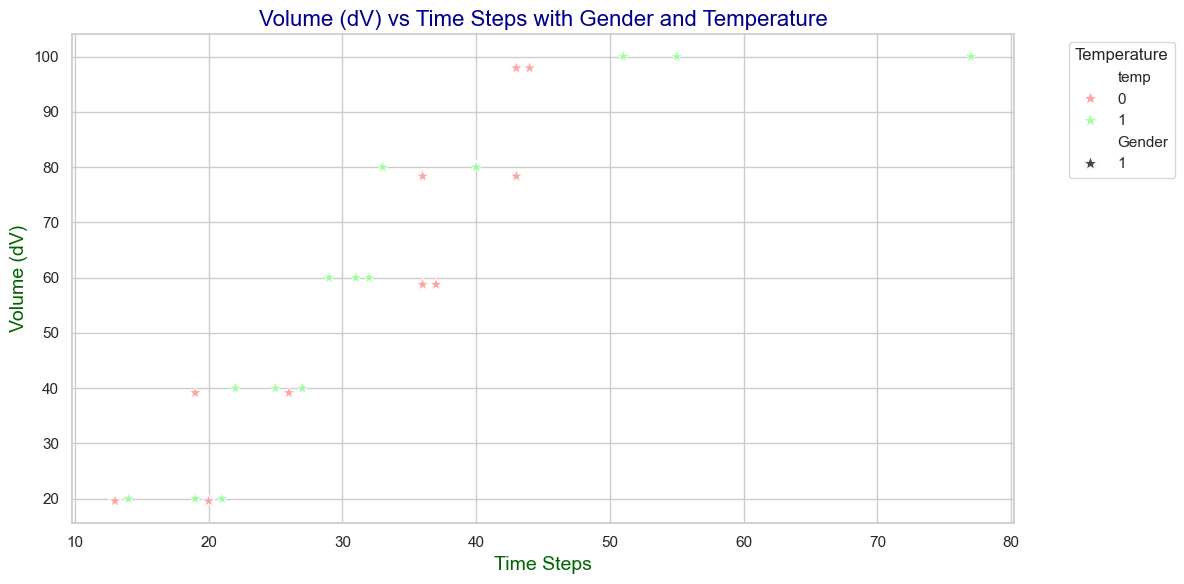

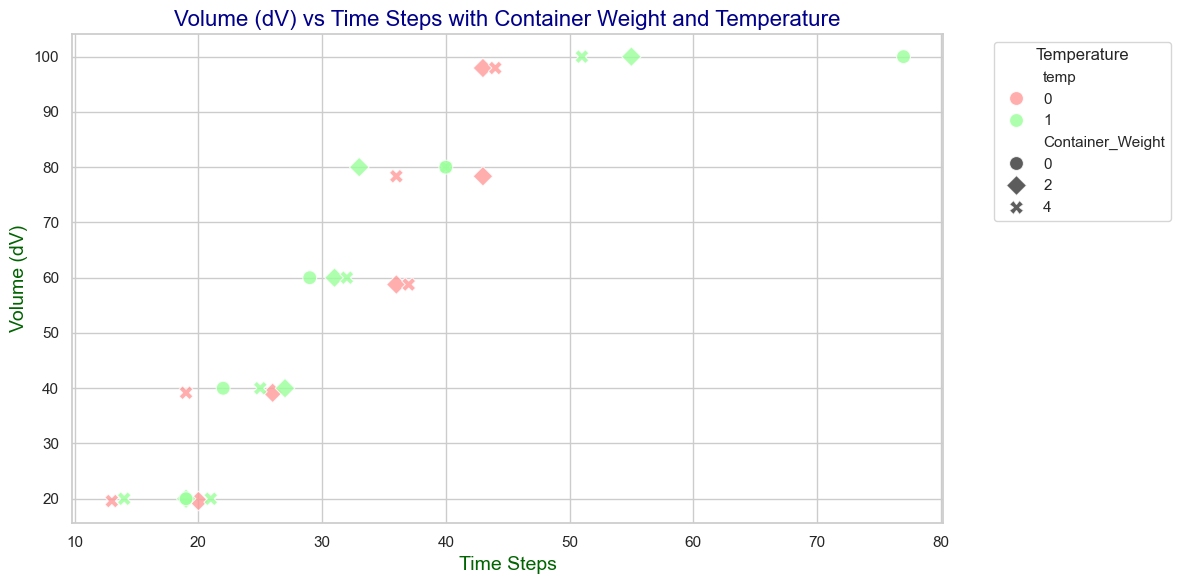

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Container Weight Color Palette with Distinct Colors
container_weight_palette = {
    0: '#1f77b4',   # Color for Container_Weight = 0
    1: '#ff7f0e',   # Color for Container_Weight = 1
    2: '#2ca02c',   # Color for Container_Weight = 2
    3: '#d62728',   # Color for Container_Weight = 3
    4: '#9467bd',   # Color for Container_Weight = 4
}

# Temperature Color Palette with Brighter Colors
temp_palette = {
    0: '#ff9999',  # Color for temp = 0 (h)
    1: '#99ff99',  # Color for temp = 1 (n)
    2: '#9999ff'   # Color for temp = 2 (c)
}

# Create distinct markers for Gender
markers = {0: "s", 1: "*"}  # 0: Female (square), 1: Male (star)

# Create a scatter plot of volume (dV) vs time_steps by gender
plt.figure(figsize=(12, 6))
sns.scatterplot(data=grouped_data1, 
                x='time_steps', 
                y='dV', 
                hue='temp',               # Hue based on Temperature
                palette=temp_palette,     # Use the temp color palette
                style='Gender',           # Different markers for Gender
                markers=markers, 
                legend='full',
                s=100,                    # Increase marker size for visibility
                alpha=0.9,                # Adjust transparency
                edgecolor='w')            # Add edge color for better visibility

# Adding titles and labels with colors for visibility
plt.title("Volume (dV) vs Time Steps with Gender and Temperature", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the first plot
plt.tight_layout()
plt.show()

# Create a new scatter plot of volume (dV) vs time_steps by container weight
plt.figure(figsize=(12, 6))

# Assign distinct markers for each container weight
container_markers = {0: "o", 1: "s", 2: "D", 3: "P", 4: "X"}  # Circle, Square, Diamond, Pentagon, X

# Scatter plot with Container Weight and Temperature
sns.scatterplot(data=grouped_data1, 
                x='time_steps', 
                y='dV', 
                hue='temp',                # Hue based on Temperature
                palette=temp_palette,      # Use the temp color palette
                style='Container_Weight',  # Different markers for Container Weight
                markers=container_markers,  # Assign different markers
                legend='full',
                s=100,                    # Increase marker size for visibility
                alpha=0.8,                # Adjust transparency
                edgecolor='w')            # Add edge color for better visibility

# Adding titles and labels with colors for visibility
plt.title("Volume (dV) vs Time Steps with Container Weight and Temperature", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the second plot
plt.tight_layout()
plt.show()

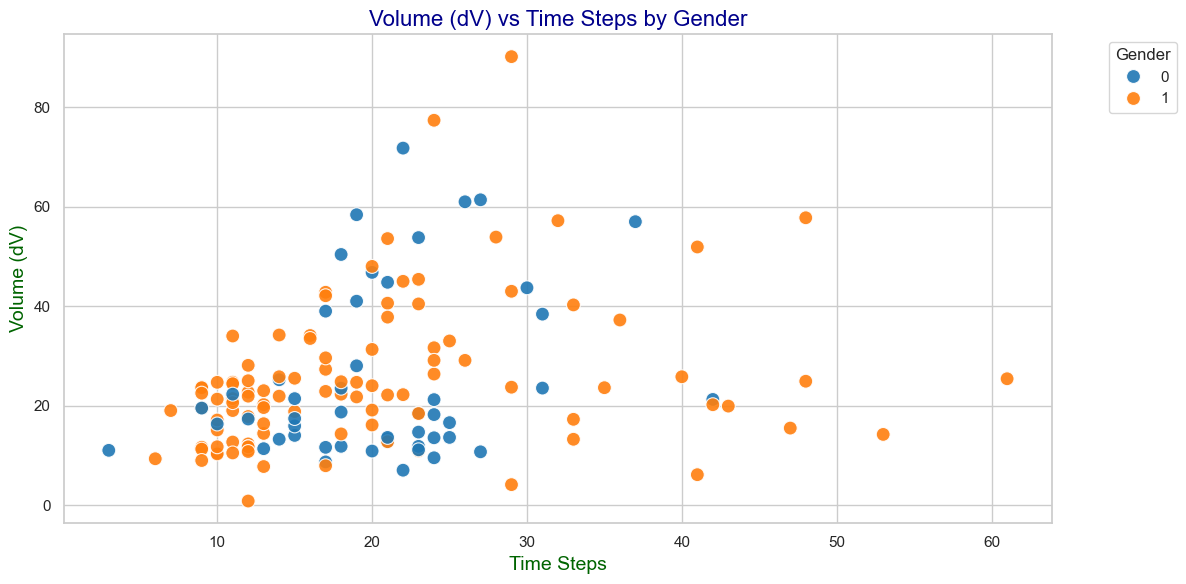


Gender Marker Mapping:
 - zero: Female
 - one: Male



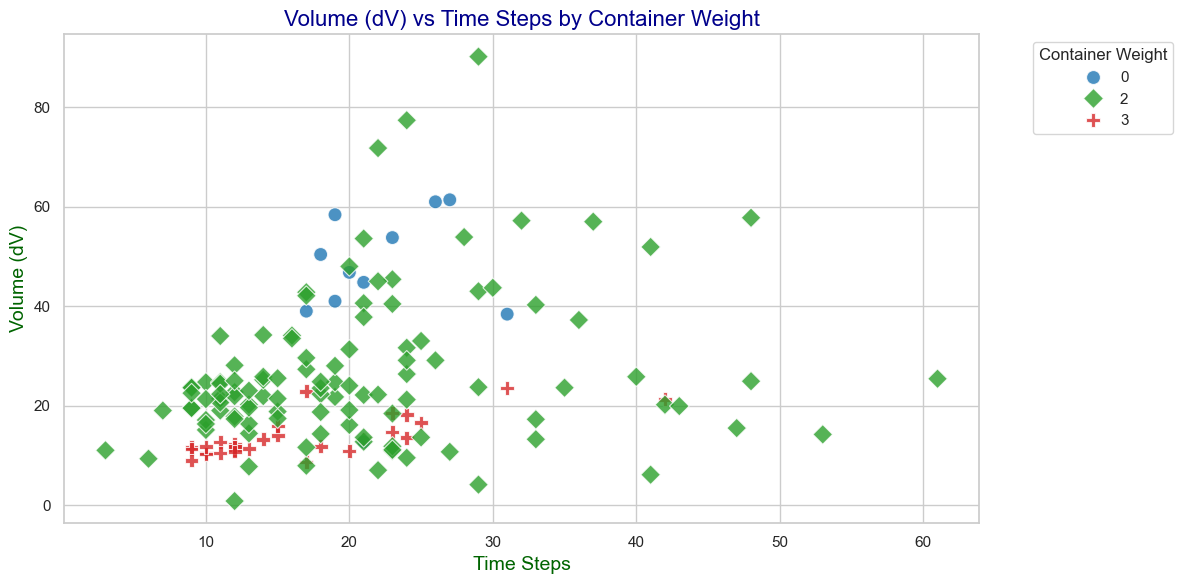


Container Weight Color Mapping:
 - Blue (#1f77b4): Weight 7.7 =water bottle= 0
 - Orange (#ff7f0e): Weight 10.9= coffee cup= 1
 - Green (#2ca02c): Weight 12.7 = plastic cup=2
 - Red (#d62728): Weight 19.8= coke=3
 - Purple (#9467bd): Weight 359= mug=4


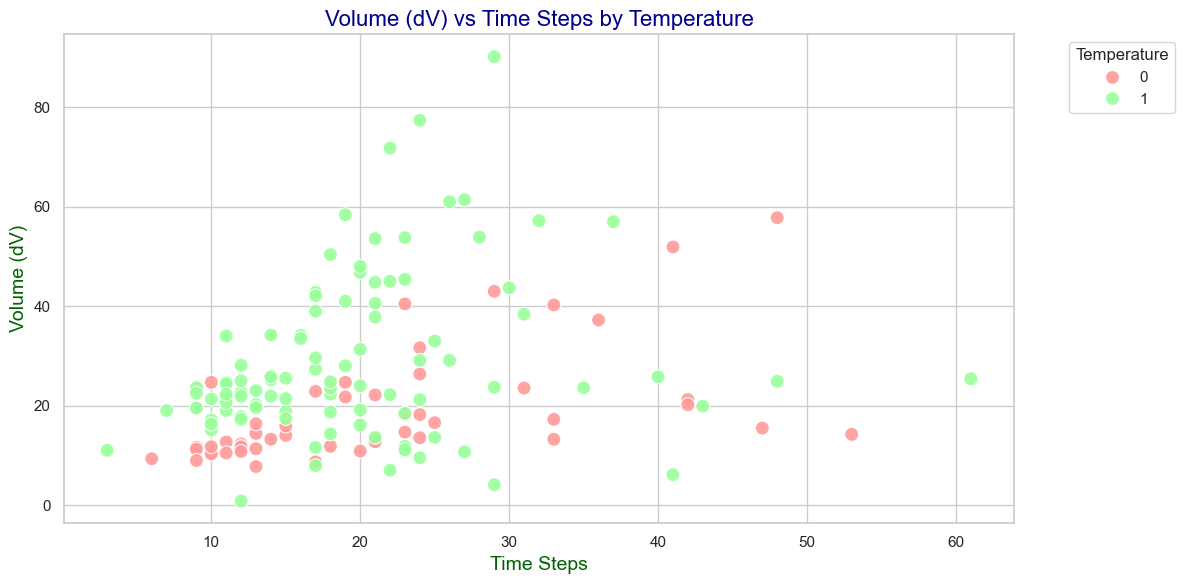

Temperature Color Mapping:
 - Red (#ff9999): Hot
 - Green (#99ff99): Normal
 - Blue (#9999ff): Cold


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Color Palette Definition
container_weight_palette = {
    0: '#1f77b4',   # Color for Container_Weight = 0 (7.7)
    1: '#ff7f0e',   # Color for Container_Weight = 1 (10.6)
    2: '#2ca02c',   # Color for Container_Weight = 2 (10.9)
    3: '#d62728',   # Color for Container_Weight = 3 (12.7)
    4: '#9467bd',   # Color for Container_Weight = 4 (19.8)
}

# Temperature Color Palette
temp_palette = {
    0: '#ff9999',  # Color for temp = 0 (Hot)
    1: '#99ff99',  # Color for temp = 1 (Normal)
    2: '#9999ff'   # Color for temp = 2 (Cold)
}

# Create distinct markers for Gender
gender_markers = {0: "s", 1: "*"}  # 0: Female (square), 1: Male (star)

# Plot 1: Volume (dV) vs Time Steps by Gender
plt.figure(figsize=(12, 6))
sns.scatterplot(data=grouped_data2, 
                x='time_steps', 
                y='dV', 
                hue='Gender',              # Hue based on Gender
                palette={0: '#1f77b4', 1: '#ff7f0e'},  # Colors for Gender
                markers=gender_markers,    # Distinct markers for Gender
                legend='full',
                s=100,                     # Increase marker size for visibility
                alpha=0.9,                 # Adjust transparency
                edgecolor='w')             # Add edge color for better visibility

# Adding titles and labels for Gender Plot
plt.title("Volume (dV) vs Time Steps by Gender", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the Gender Plot
plt.tight_layout()
plt.show()
print("\nGender Marker Mapping:")  
print(" - zero: Female")  
print(" - one: Male\n")  
# Plot 2: Volume (dV) vs Time Steps by Container Weight
plt.figure(figsize=(12, 6))
# Distinct markers for Container Weight
container_markers = {0: "o", 1: "s", 2: "D", 3: "P", 4: "X"}  # Circle, Square, Diamond, Pentagon, X

# Scatter plot with Container Weight
sns.scatterplot(data=grouped_data2, 
                x='time_steps', 
                y='dV', 
                hue='Container_Weight',     # Hue based on Container Weight
                palette=container_weight_palette,  # Use distinct colors for each weight
                style='Container_Weight',   # Different markers for each Container Weight
                markers=container_markers,   # Assign different markers
                legend='full',
                s=100,                     # Increase marker size for visibility
                alpha=0.8,                 # Adjust transparency
                edgecolor='w')             # Add edge color for better visibility

# Adding titles and labels for Container Weight Plot
plt.title("Volume (dV) vs Time Steps by Container Weight", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Container Weight', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the Container Weight Plot
plt.tight_layout()
plt.show()
print("\nContainer Weight Color Mapping:")  
print(" - Blue (#1f77b4): Weight 7.7 =water bottle= 0")  
print(" - Orange (#ff7f0e): Weight 10.9= coffee cup= 1")  
print(" - Green (#2ca02c): Weight 12.7 = plastic cup=2")  
print(" - Red (#d62728): Weight 19.8= coke=3")  
print(" - Purple (#9467bd): Weight 359= mug=4")  
# Plot 3: Volume (dV) vs Time Steps by Temperature
plt.figure(figsize=(12, 6))
# Scatter plot with Temperature
sns.scatterplot(data=grouped_data2, 
                x='time_steps', 
                y='dV', 
                hue='temp',               # Hue based on Temperature
                palette=temp_palette,     # Use the temp color palette
                legend='full',
                s=100,                    # Increase marker size for visibility
                alpha=0.9,                # Adjust transparency
                edgecolor='w')            # Add edge color for better visibility

# Adding titles and labels for Temperature Plot
plt.title("Volume (dV) vs Time Steps by Temperature", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the Temperature Plot
plt.tight_layout()
plt.show()
print("Temperature Color Mapping:")  
print(" - Red (#ff9999): Hot")  
print(" - Green (#99ff99): Normal")  
print(" - Blue (#9999ff): Cold")  




In [4]:
# train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
# X_train = X_P.iloc[:train_size]
# y_train = y_P.iloc[:train_size]
# X_test = X_P.iloc[train_size:]
# y_test = y_P.iloc[train_size:]
# X_train = X
# y_train = y
# X_test = X_P
# y_test = y_P


In [48]:

# Create a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)




In [7]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [29]:
model = SVR(kernel='poly')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [5]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [31]:
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

Mean Squared Error (MSE): 314.6139
Root Mean Squared Error (RMSE): 17.7374
R-squared (R²): 0.3252
Root Mean Squared Percentage Error (RMSPE): 388.9973%
         Actual  Predicted
154   33.000000  35.327811
160   21.200000  34.722353
31    14.000000  13.968578
153   31.300000  19.845628
7     60.000000  42.590532
29    13.333333  17.870440
63    11.238095  10.487683
171   11.800000  26.462591
100   23.700000  21.783961
65    11.714286  10.420254
61    10.476190  12.014063
118   17.800000  23.119030
103   15.100000  20.901450
14    19.588639  19.750559
12    58.765916  63.030742
69    20.176298  37.549550
86    24.681685  23.062346
24    40.000000  44.172400
133   19.500000  21.783961
11    78.354554  59.546701
43    12.700000  45.108665
15   100.000000  49.986943
176    0.800000  23.119030
76    42.997062  41.961622
50    15.904762  13.968578
60    10.761905  11.725447
177   22.500000  21.783961
77    40.254652  35.916691
66    14.201763  83.298164
147   23.000000  14.565337
144   48.00

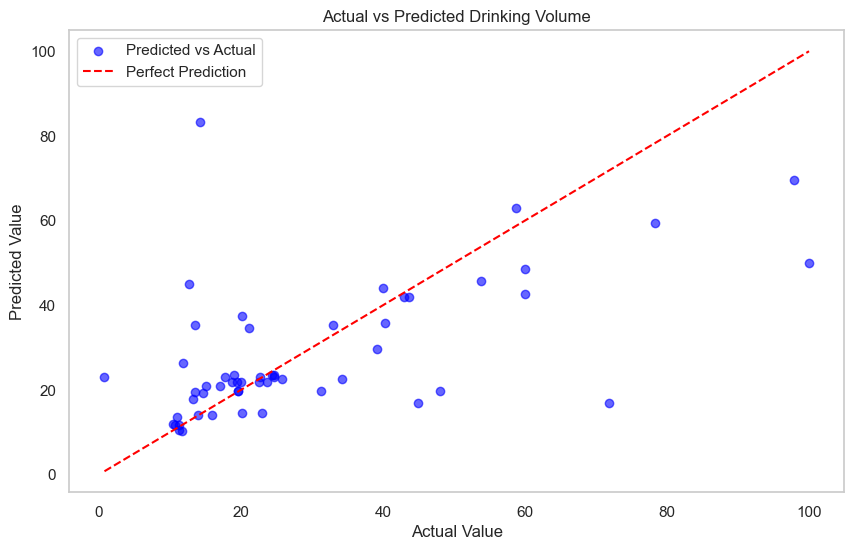

In [7]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(50))
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted Drinking Volume')
plt.legend()
plt.grid()
plt.show()

         Actual  Predicted  Container_Weight
154   33.000000  35.327811                 2
160   21.200000  34.722353                 2
31    14.000000  13.968578                 3
153   31.300000  19.845628                 2
7     60.000000  42.590532                 2
29    13.333333  17.870440                 3
63    11.238095  10.487683                 3
171   11.800000  26.462591                 2
100   23.700000  21.783961                 2
65    11.714286  10.420254                 3
61    10.476190  12.014063                 3
118   17.800000  23.119030                 2
103   15.100000  20.901450                 2
14    19.588639  19.750559                 4
12    58.765916  63.030742                 4
69    20.176298  37.549550                 2
86    24.681685  23.062346                 2
24    40.000000  44.172400                 0
133   19.500000  21.783961                 2
11    78.354554  59.546701                 4
43    12.700000  45.108665                 0
15   100.0

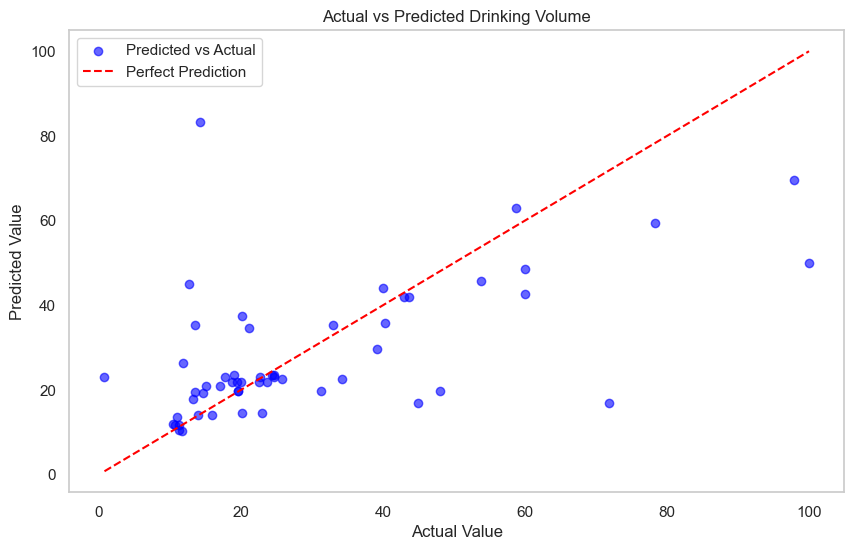

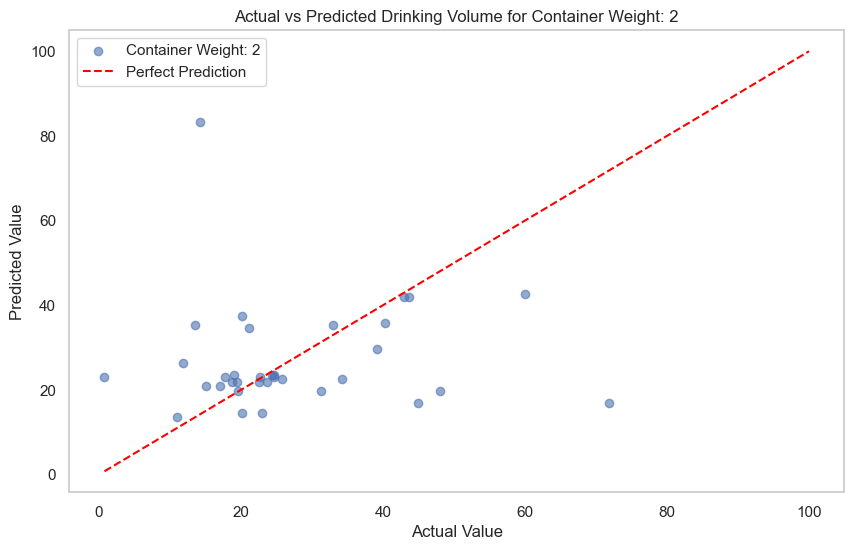

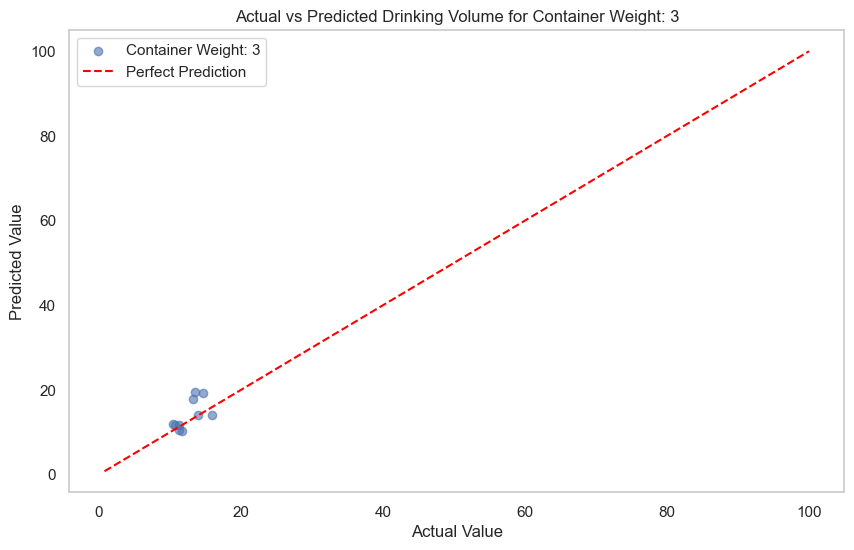

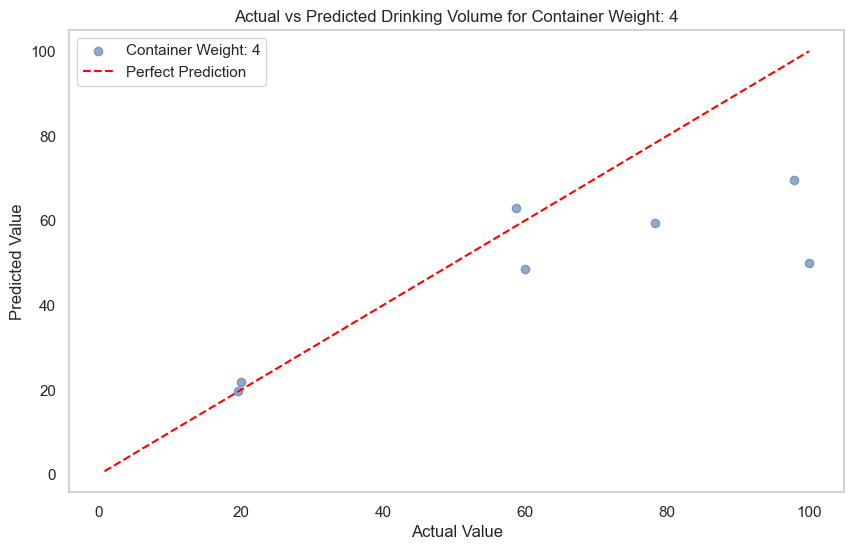

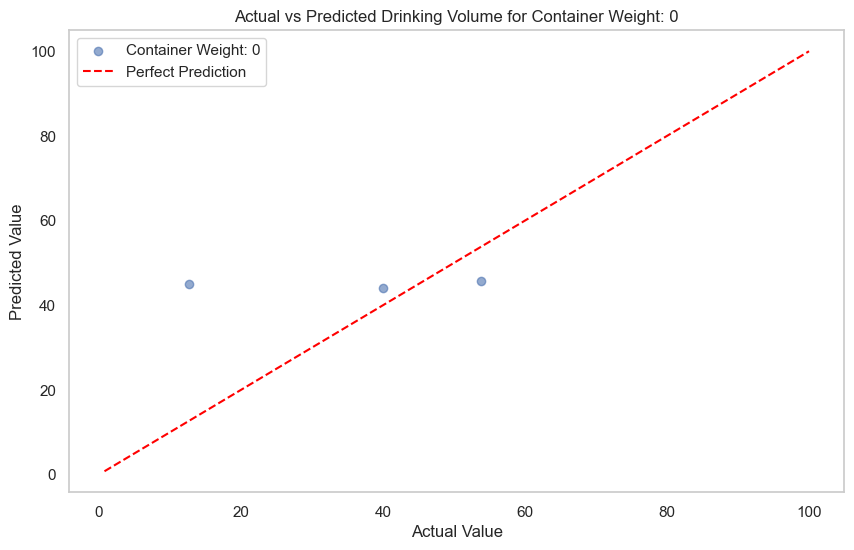

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Assuming y_test, y_pred, and combined_data are already defined, and you have the training model.

# Create a DataFrame for comparisons
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Add the Container_Weight to the comparison DataFrame
comparison_df['Container_Weight'] = combined_data.loc[X_test.index, 'Container_Weight'].values
print(comparison_df)
# Calculate metrics for each Container Weight category
container_metrics = {}
for weight in comparison_df['Container_Weight'].unique():
    mask = comparison_df['Container_Weight'] == weight
    actuals = comparison_df.loc[mask, 'Actual']
    predictions = comparison_df.loc[mask, 'Predicted']
    
    if len(actuals) > 0:  # Ensure there are actual samples to evaluate
        mse = mean_squared_error(actuals, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(actuals, predictions)
        rmspe = np.sqrt(np.mean(((actuals - predictions) / actuals) ** 2)) * 100  # Percentage error
        print('weight', weight)
        container_metrics[weight] = {
            'MSE': mse,
            'RMSE': rmse,
            'R²': r2,
            'RMSPE (%)': rmspe
        }

# Convert metrics to a DataFrame for better visualization
metrics_df = pd.DataFrame(container_metrics).T
print("\nPerformance Metrics by Container Weight:")
print(metrics_df)

# Visualizing Actual vs Predicted values for the entire dataset
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted Drinking Volume')
plt.legend()
plt.grid()
plt.show()

# Plot Actual vs Predicted values by Container Weight
for weight in comparison_df['Container_Weight'].unique():
    mask = comparison_df['Container_Weight'] == weight
    plt.figure(figsize=(10, 6))
    plt.scatter(comparison_df.loc[mask, 'Actual'], comparison_df.loc[mask, 'Predicted'], alpha=0.6, label=f'Container Weight: {weight}')
    plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()], 
             [comparison_df['Actual'].min(), comparison_df['Actual'].max()], 
             color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Drinking Volume for Container Weight: {weight}')
    plt.legend()
    plt.grid()
    plt.show()

In [81]:
print("Indices of X_test:", X_test.index)
print("Indices of combined_data:", combined_data.index)
print("X_test",X_test)

Indices of X_test: Index([158, 234, 423,  64, 102, 395, 267,  69, 282,   0,
       ...
       370, 250, 294, 142, 320, 232,  19, 384, 212,  31],
      dtype='int64', length=133)
Indices of combined_data: Index([149, 314, 214,  95,  19, 182,  44, 212,  16, 146,
       ...
        89,  71, 252, 403,  88, 380, 310, 389,  43, 215],
      dtype='int64', length=443)
X_test      time_steps  Container_Weight
158          27                 1
234          13                 3
423          11                 2
64           10                 0
102         121                 2
..          ...               ...
232          13                 3
19           11                 2
384           9                 2
212          17                 0
31           30                 4

[133 rows x 2 columns]


X_test before extraction:
     time_steps  Container_Weight
158          27                 1
234          13                 3
423          11                 2
64           10                 0
102         121                 2
Comparison DataFrame with Container Weight:
         Actual   Predicted  Container_Weight
158   20.337302   58.771846                 1
234   68.285714   22.906332                 3
423   46.500000   35.803841                 2
64    20.000000   49.961230                 0
102   57.142857   56.740688                 2
395   17.361111   37.323953                 4
267   36.238981   68.687467                 2
69    20.000000   49.961230                 0
282   29.400000   27.313290                 2
0    100.000000   42.845902                 2
35    99.206349   24.602178                 4
410  121.924603   16.099657                 4
251   17.531832   26.996820                 3
208   69.637610   18.590024                 3
2     60.000000   37.435844         

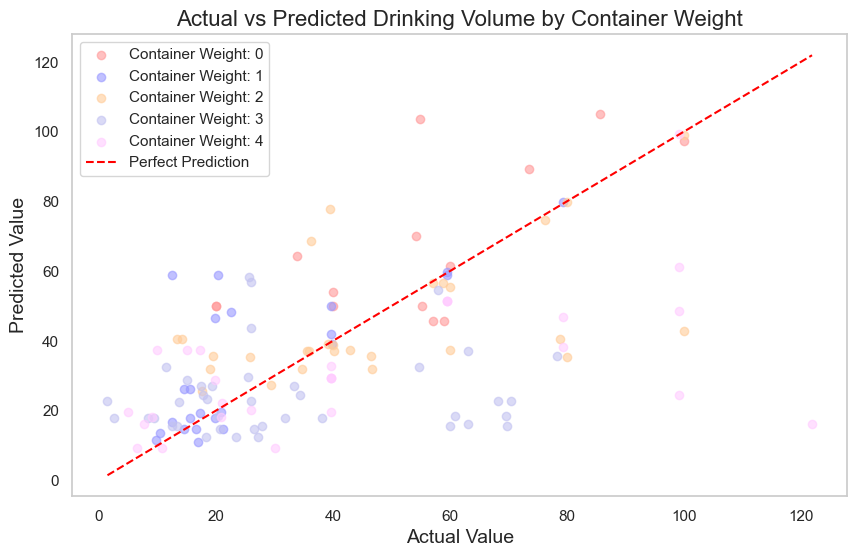

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Create DataFrame for Actual and Predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Confirm that X_test contains the necessary information
print("X_test before extraction:")
print(X_test.head())  # Print the first few rows to confirm structure

# Add the Container_Weight from X_test to comparison_df
comparison_df['Container_Weight'] = X_test.loc[comparison_df.index, 'Container_Weight'].values

# Print the updated comparison_df to ensure Container_Weight has been added correctly
print("Comparison DataFrame with Container Weight:")
print(comparison_df.head(50))  # Show the first 50 rows for verification

# Define color palette for Container Weights for visualization
container_weight_palette = {
    0: '#ff9999',  # Color for weight 0
    1: '#9999ff',  # Combined Color for weights 10.6 and 10.9
    2: '#ffcc99',  # Color for weight 2
    3: '#c2c2f0',  # Color for weight 3
    4: '#ffccff'   # Color for weight 4
}

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")
print(comparison_df.head(50))  # Show the comparison DataFrame

# Visualization: Plot Actual vs Predicted values with Container Weight specifications
plt.figure(figsize=(10, 6))

# Create a scatter plot for each container weight
for container_value, color in container_weight_palette.items():
    mask = comparison_df['Container_Weight'] == container_value
    plt.scatter(comparison_df.loc[mask, 'Actual'], 
                comparison_df.loc[mask, 'Predicted'], 
                color=color, 
                label=f'Container Weight: {container_value}', 
                alpha=0.6)

# Plot perfect prediction line
plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()], 
         [comparison_df['Actual'].min(), comparison_df['Actual'].max()], 
         color='red', ls='--', label='Perfect Prediction')

# Set labels and title
plt.xlabel('Actual Value', fontsize=14)
plt.ylabel('Predicted Value', fontsize=14)
plt.title('Actual vs Predicted Drinking Volume by Container Weight', fontsize=16)
plt.legend()
plt.grid()
plt.show()

        Actual  Predicted  Container_Weight
158  20.337302  58.771846                 1
234  68.285714  22.906332                 3
423  46.500000  35.803841                 2
64   20.000000  49.961230                 0
102  57.142857  56.740688                 2
..         ...        ...               ...
232  70.476190  22.906332                 3
19   19.588639  35.803841                 2
384  17.700000  25.738095                 2
212  59.000000  45.687121                 0
31   79.365079  38.253364                 4

[133 rows x 3 columns]
Weight: 1
MSE: 237.98, RMSE: 15.43, R²: 0.26, RMSPE (%): 97.93
Weight: 3
MSE: 609.69, RMSE: 24.69, R²: -0.30, RMSPE (%): 256.62
Weight: 2
MSE: 435.55, RMSE: 20.87, R²: 0.25, RMSPE (%): 65.66
Weight: 0
MSE: 473.98, RMSE: 21.77, R²: 0.01, RMSPE (%): 68.50
Weight: 4
MSE: 966.70, RMSE: 31.09, R²: 0.18, RMSPE (%): 95.59

Performance Metrics by Container Weight:
          MSE       RMSE        R²   RMSPE (%)
1  237.975731  15.426462  0.262850   97.93

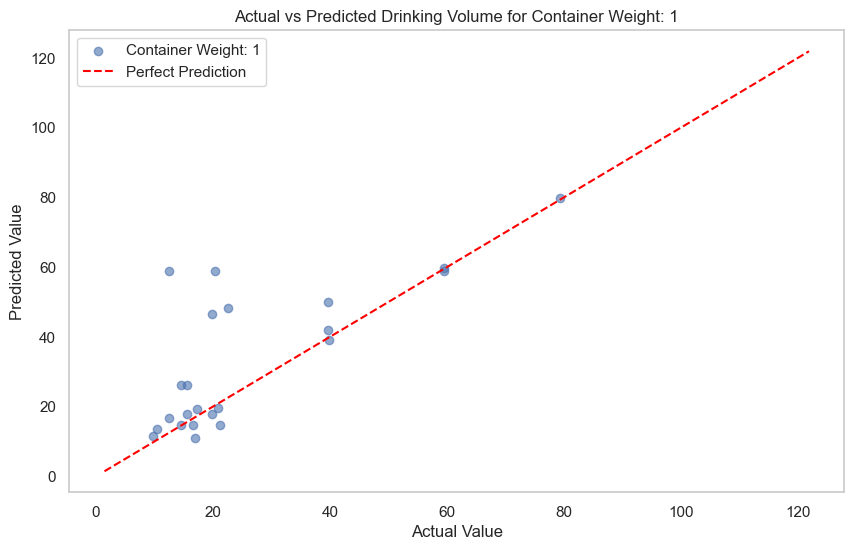

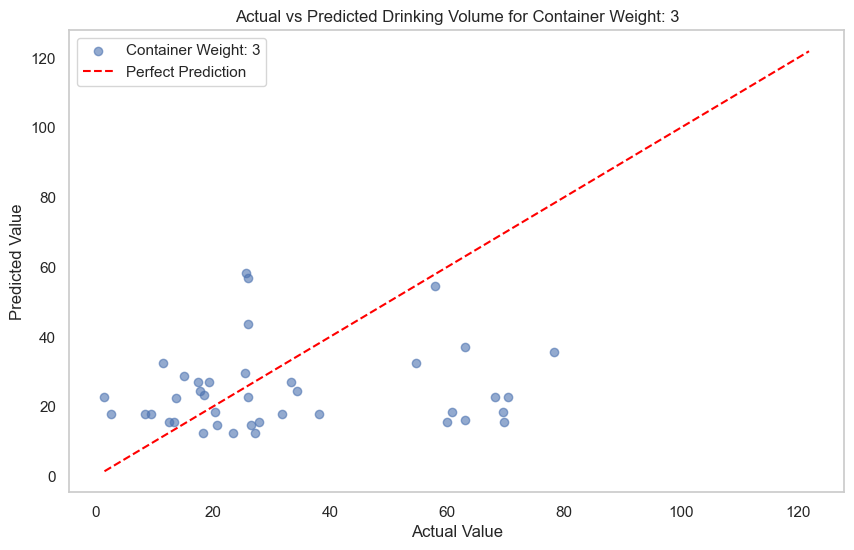

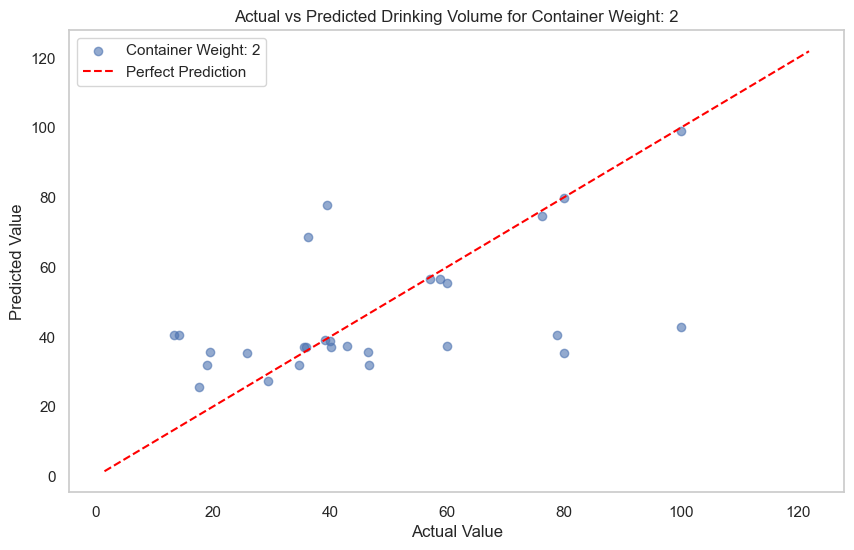

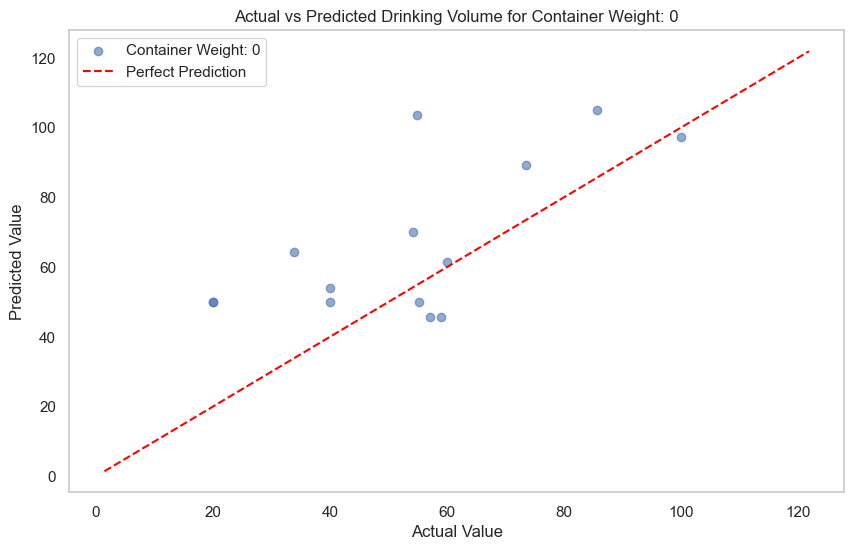

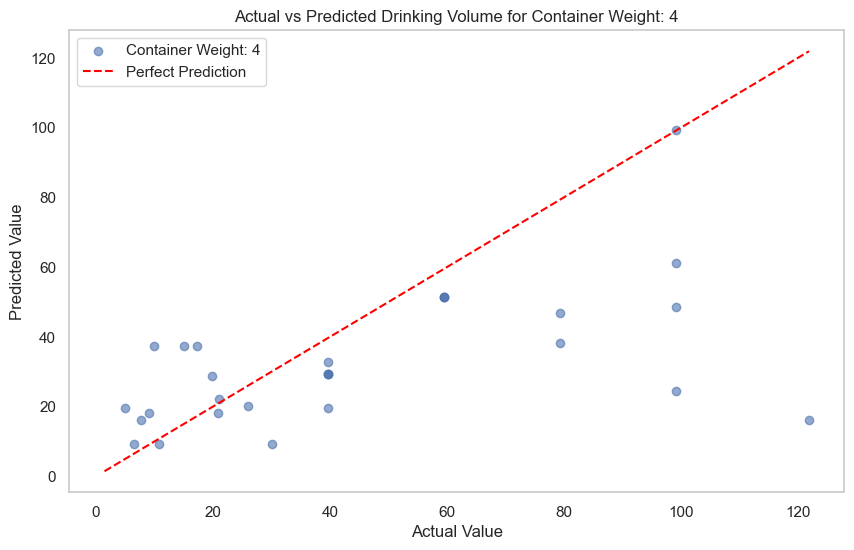

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Assuming y_test, y_pred, and combined_data are already defined, and you have the training model.
# Create a DataFrame for comparisons
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Add the Container_Weight to the comparison DataFrame
comparison_df['Container_Weight'] = combined_data.loc[X_test.index, 'Container_Weight'].values
print(comparison_df)

# Calculate metrics for each Container Weight category
container_metrics = {}
for weight in comparison_df['Container_Weight'].unique():
    mask = comparison_df['Container_Weight'] == weight
    actuals = comparison_df.loc[mask, 'Actual']
    predictions = comparison_df.loc[mask, 'Predicted']
    
    if len(actuals) > 0:  # Ensure there are actual samples to evaluate
        mse = mean_squared_error(actuals, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(actuals, predictions)
        rmspe = np.sqrt(np.mean(((actuals - predictions) / actuals) ** 2)) * 100  # Percentage error
        
        # Store metrics for each container weight
        container_metrics[weight] = {
            'MSE': mse,
            'RMSE': rmse,
            'R²': r2,
            'RMSPE (%)': rmspe
        }

        # Print metrics for the current weight
        print(f'Weight: {weight}')
        print(f'MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}, RMSPE (%): {rmspe:.2f}')

# Convert metrics to a DataFrame for better visualization
metrics_df = pd.DataFrame(container_metrics).T
print("\nPerformance Metrics by Container Weight:")
print(metrics_df)

# Visualizing Actual vs Predicted values for each Container Weight separately
for weight in comparison_df['Container_Weight'].unique():
    mask = comparison_df['Container_Weight'] == weight
    plt.figure(figsize=(10, 6))
    plt.scatter(comparison_df.loc[mask, 'Actual'], 
                comparison_df.loc[mask, 'Predicted'], 
                alpha=0.6, label=f'Container Weight: {weight}')
    plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()], 
             [comparison_df['Actual'].min(), comparison_df['Actual'].max()], 
             color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Drinking Volume for Container Weight: {weight}')
    plt.legend()
    plt.grid()
    plt.show()

Explained Variance by Principal Components:
Principal Component 1: 0.9995
Principal Component 2: 0.0005

Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 621.2106
Root Mean Squared Error (RMSE): 24.9241
R-squared (R²): 0.1171
Root Mean Squared Percentage Error (RMSPE): 204.7097%
        Actual  Predicted
158  20.337302  45.802751
234  68.285714  28.431361
423  46.500000  34.977689
64   20.000000  48.783467
102  57.142857  61.125511


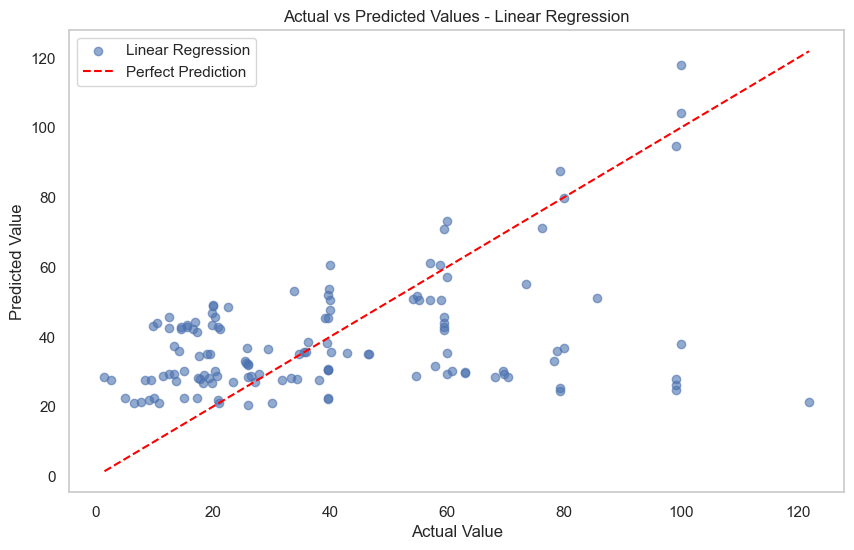


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 636.3671
Root Mean Squared Error (RMSE): 25.2263
R-squared (R²): 0.0956
Root Mean Squared Percentage Error (RMSPE): 184.9554%
        Actual  Predicted
158  20.337302  29.074412
234  68.285714  26.395466
423  46.500000  26.296722
64   20.000000  26.389491
102  57.142857  53.588905


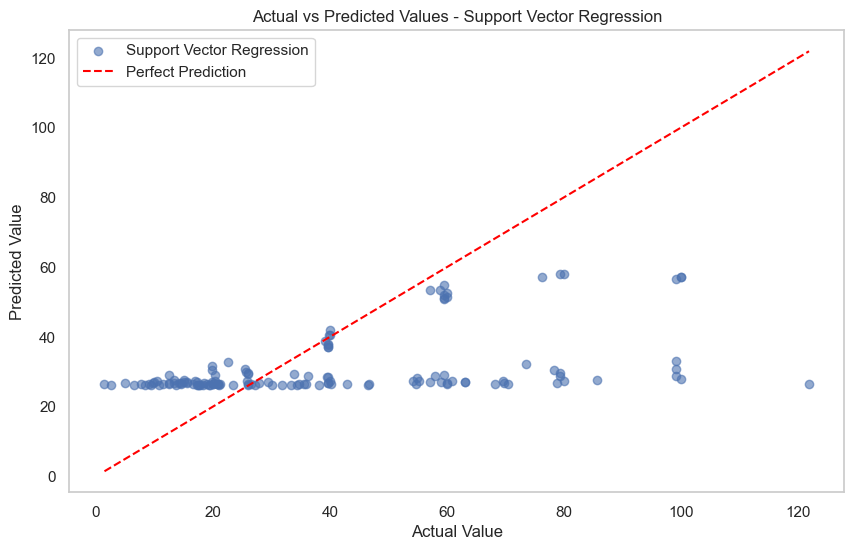


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 659.6122
Root Mean Squared Error (RMSE): 25.6829
R-squared (R²): 0.0626
Root Mean Squared Percentage Error (RMSPE): 158.3465%
        Actual  Predicted
158  20.337302  59.523810
234  68.285714  22.922640
423  46.500000  35.866667
64   20.000000  40.000000
102  57.142857  60.000000


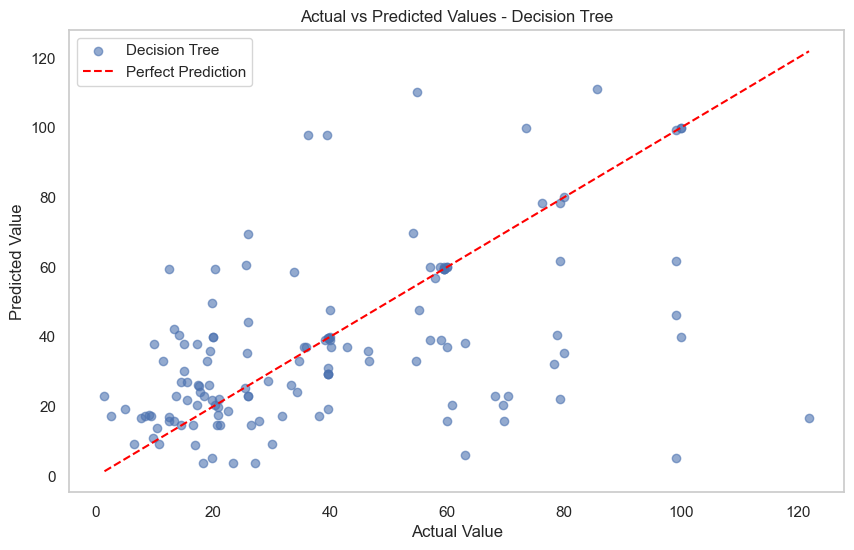


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 555.3157
Root Mean Squared Error (RMSE): 23.5651
R-squared (R²): 0.2108
Root Mean Squared Percentage Error (RMSPE): 158.3228%
        Actual  Predicted
158  20.337302  63.945070
234  68.285714  22.906332
423  46.500000  35.803841
64   20.000000  48.908385
102  57.142857  56.334339


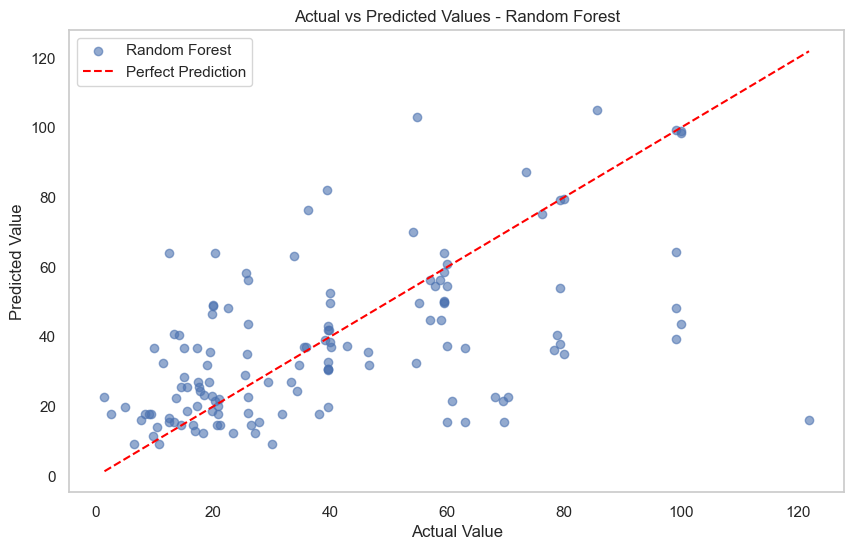


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 485.2119
Root Mean Squared Error (RMSE): 22.0275
R-squared (R²): 0.3104
Root Mean Squared Percentage Error (RMSPE): 159.1987%
        Actual  Predicted
158  20.337302  54.079008
234  68.285714  23.749688
423  46.500000  33.972004
64   20.000000  38.553016
102  57.142857  59.257822


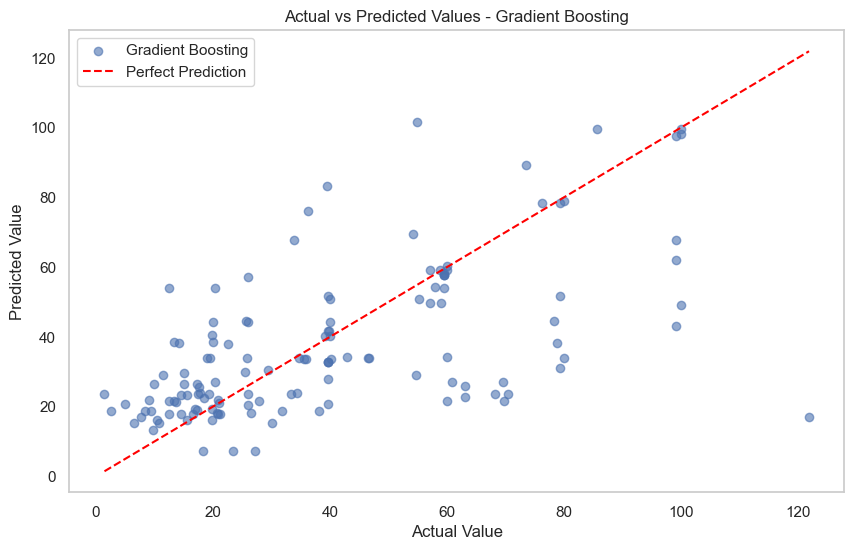


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 546.9289
Root Mean Squared Error (RMSE): 23.3865
R-squared (R²): 0.2227
Root Mean Squared Percentage Error (RMSPE): 169.6275%
        Actual  Predicted
158  20.337302  71.714286
234  68.285714  24.745170
423  46.500000  32.720000
64   20.000000  21.357778
102  57.142857  55.746032


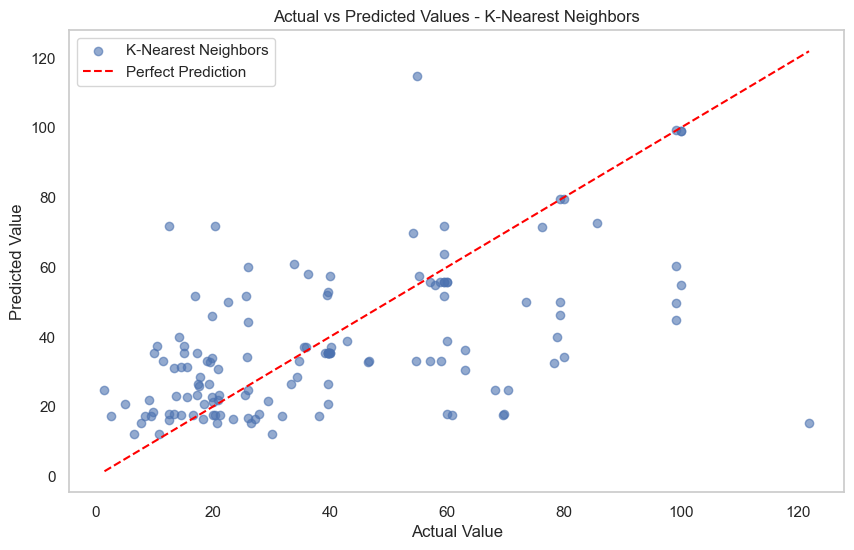


PCA Loadings:
                        PC1       PC2
time_steps        58.155456  0.001855
Container_Weight  -0.086230  1.251135


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA

# Assuming X_train, X_test, y_train, y_test are already defined

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store evaluation results
results = {}

# Fit PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Model evaluation
for model_name, model in models.items():
    # Fit the model
    model.fit(X_train_pca, y_train)

    # Make predictions
    y_pred = model.predict(X_test_pca)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

# Analyzing Loadings of PCA

# Determine if X_train is a DataFrame or a NumPy array
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns
else:
    # If X_train is a NumPy array, you can use default feature names (e.g., "Feature 1", "Feature 2", ...)
    feature_names = [f'Feature {i+1}' for i in range(X_train.shape[1])]

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])], index=feature_names)

print("\nPCA Loadings:")
print(loading_df)

In [35]:
# Assuming X_train is your original feature set

# Fit PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Analyzing Loadings of PCA

# Use the column names from the original DataFrame
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.tolist()
else:
    # If it's a NumPy array, generate default names
    feature_names = [f'Feature {i + 1}' for i in range(X_train.shape[1])]

# Calculate the loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)  # Loadings calculated as explained variance
loading_df = pd.DataFrame(loadings, columns=[f'PC{i + 1}' for i in range(pca.components_.shape[0])], index=feature_names)

# Display peak contributions
print("\nPCA Loadings:")
print(loading_df)

# Optional: To better understand which features contribute to each component
print("\nContribution of Features to Principal Components (sorted):")
for i in range(loadings.shape[1]):
    print(f"Principal Component {i + 1}:")
    sorted_indices = np.argsort(np.abs(loadings[:, i]))[::-1]  # Sort by absolute value
    for index in sorted_indices:
        print(f"{feature_names[index]}: {loadings[index, i]:.4f}")

Explained Variance by Principal Components:
Principal Component 1: 0.9803
Principal Component 2: 0.0131

PCA Loadings:
                 PC1       PC2
time_steps  8.948601  0.092689
temp        0.188637  0.613849
sip_id     -1.129380  0.836950

Contribution of Features to Principal Components (sorted):
Principal Component 1:
time_steps: 8.9486
sip_id: -1.1294
temp: 0.1886
Principal Component 2:
sip_id: 0.8369
temp: 0.6138
time_steps: 0.0927


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# Sample DataFrame with 4 features for demonstration
features = df[['time_steps', 'Gender', 'Container_Weight', 'temp', 'sip_id']]

# Optional: Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Fit PCA
pca = PCA(n_components=2)  # Adjust n_components as needed
X_pca = pca.fit_transform(features_scaled)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Loading results
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, index=features.columns, columns=[f'PC{i + 1}' for i in range(loadings.shape[1])])

# Display PCA Loadings
print("\nPCA Loadings:")
print(loading_df)

# Contribution of Features to Principal Components
print("\nContribution of Features to Principal Components (sorted):")
for i in range(loadings.shape[1]):
    print(f"\nPrincipal Component {i + 1}:")
    sorted_indices = np.argsort(np.abs(loadings[:, i]))[::-1]  # Sort by absolute loading values
    for index in sorted_indices:
        print(f"{features.columns[index]}: {loadings[index, i]:.4f}")

# Optional: Visualize the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, label='PCA Projection')
plt.title('PCA of Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.legend()
plt.show()

KeyError: "['time_steps'] not in index"


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 129.0847
Root Mean Squared Error (RMSE): 11.3615
R-squared (R²): 0.8243
Root Mean Squared Percentage Error (RMSPE): 33.9186%
    Actual  Predicted
56      80  94.622436
57      60  80.197723
58      40  57.733071
59      20  40.092382
60     100  89.441105


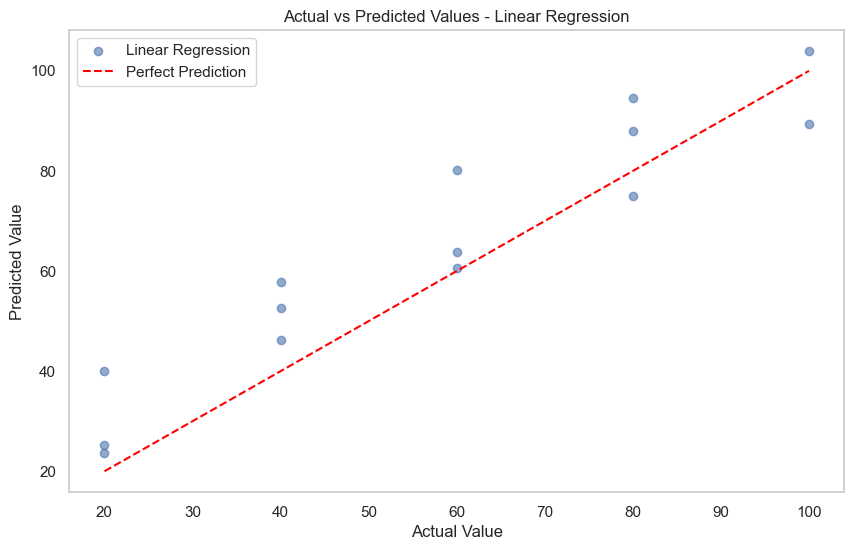


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 420.9581
Root Mean Squared Error (RMSE): 20.5173
R-squared (R²): 0.4270
Root Mean Squared Percentage Error (RMSPE): 70.2413%
    Actual  Predicted
56      80  70.115554
57      60  69.535660
58      40  60.008501
59      20  50.441208
60     100  68.910601


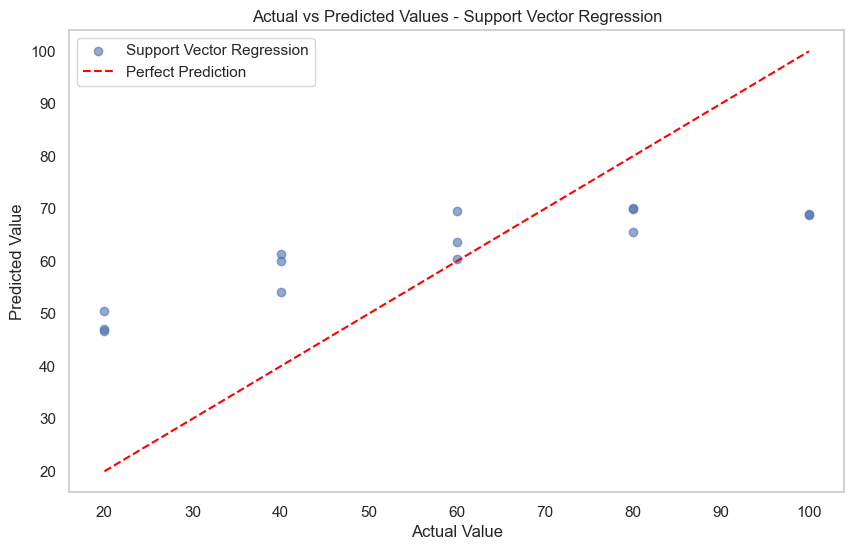


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 200.0000
Root Mean Squared Error (RMSE): 14.1421
R-squared (R²): 0.7278
Root Mean Squared Percentage Error (RMSPE): 37.6650%
    Actual  Predicted
56      80      100.0
57      60       80.0
58      40       60.0
59      20       40.0
60     100      100.0


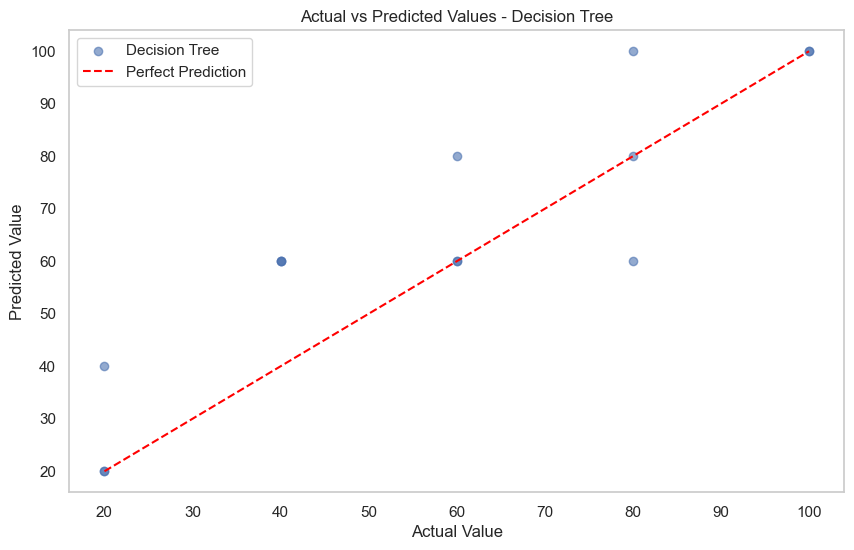


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 210.4914
Root Mean Squared Error (RMSE): 14.5083
R-squared (R²): 0.7135
Root Mean Squared Percentage Error (RMSPE): 38.8663%
    Actual  Predicted
56      80       95.4
57      60       86.8
58      40       64.8
59      20       39.6
60     100       93.8


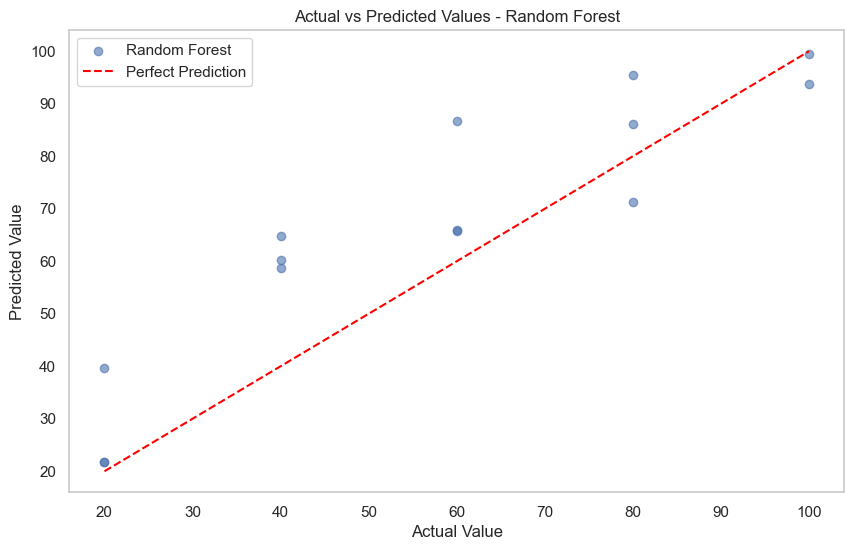


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 308.5367
Root Mean Squared Error (RMSE): 17.5652
R-squared (R²): 0.5800
Root Mean Squared Percentage Error (RMSPE): 43.7671%
    Actual  Predicted
56      80  92.707881
57      60  96.188814
58      40  71.327165
59      20  40.255089
60     100  98.357223


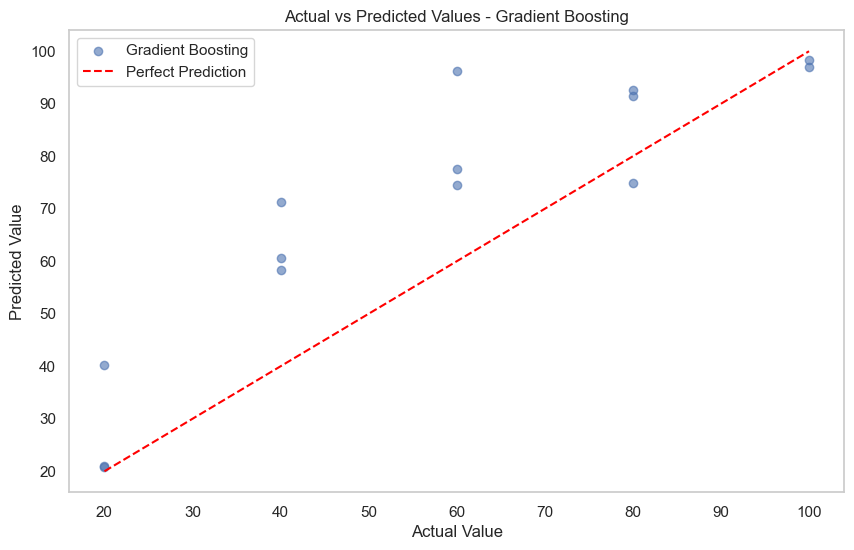


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 301.7143
Root Mean Squared Error (RMSE): 17.3699
R-squared (R²): 0.5893
Root Mean Squared Percentage Error (RMSPE): 48.4821%
    Actual  Predicted
56      80       92.0
57      60       80.0
58      40       72.0
59      20       44.0
60     100       88.0


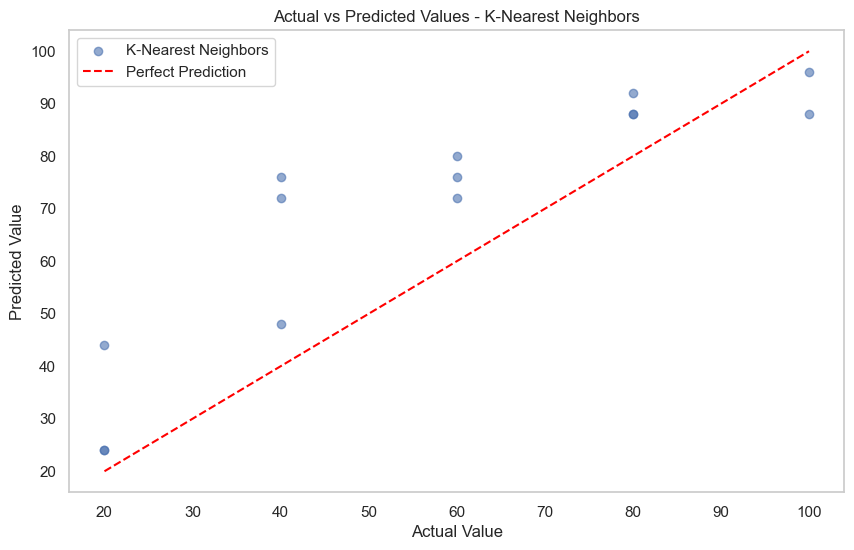

In [37]:
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    # "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2)

    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have already defined your models and results above
# color_map = {
#     0: 'blue',
#     1: 'orange',
#     2: 'green',
#     3: 'red',
#     4: 'purple'
# }
color_map = {
    0: 'blue',    # For 7.7
    1: 'orange',  # For 10.6
    2: 'green',   # For 10.9
    3: 'red',     # For 12.7
    4: 'purple',  # For 19.8
    5: 'cyan'     # For 359
}
# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Container_Weight': X_test['Container_Weight']})
    
    # Plotting Actual vs Predicted with Container Weights
    plt.figure(figsize=(10, 6))

    for weight, group in comparison_df.groupby('Container_Weight'):
        plt.scatter(group['Actual'], group['Predicted'], 
                    label=f'Container Weight: {weight}', 
                    color=color_map[weight], 
                    alpha=0.6)
# Assuming you use the updated color mapping provided above
# for weight, group in comparison_df.groupby('Container_Weight'):
#     plt.scatter(group['Actual'], group['Predicted'], 
#                 label=f'Container Weight: {weight}', 
#                 color=color_map[weight], 
#                 alpha=0.6)
    plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
             [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
             color='black', ls='--', label='Perfect Prediction')

    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 129.0847
Root Mean Squared Error (RMSE): 11.3615
R-squared (R²): 0.8243
Root Mean Squared Percentage Error (RMSPE): 33.9186%


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# Assuming df is your DataFrame that contains 'Container_Weight' and your feature columns
# Mapping container weights to classes
df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})

# Assuming X_train and y_train are defined properly from your df DataFrame
# Define features and target variable
  # Replace with your actual target column name

# Store results for all model evaluations
overall_results = {}

# Get unique container weight classes
weight_classes = df["Container_Weight"].unique()

for category in weight_classes:
    # Filter data based on container weight class
    mask = df["Container_Weight"] == category
    X_filtered = X_train[mask]
    y_filtered = y_train[mask]

    if len(y_filtered) == 0:
        print(f"No data available for container weight category: {category}.")
        continue

    print(f"Training models for container weight category: {category}...")

    # Define your models
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf'),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    }

    # Store evaluation results for this category
    results = {}

for category in weight_classes:
    # Filter data based on container weight class
    filtered_data = df[df["Container_Weight"] == category]
    
    # Check if the filtered data is not empty
    if len(filtered_data) == 0:
        print(f"No data available for container weight category: {category}.")
        continue

    # Split filtered data into features and target
    X_filtered = filtered_data[feature_columns]
    y_filtered = filtered_data[target_column]

    print(f"Training models for container weight category: {category}...")

    # Define your models
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf'),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    }

    # Store evaluation results for this category
    results = {}

    for model_name, model in models.items():
        # Fit the model
        model.fit(X_filtered, y_filtered)

        # Make predictions using the filtered data
        y_pred = model.predict(X_filtered)  # Using the same filtered data for prediction

        # Calculate evaluation metrics
        mse = mean_squared_error(y_filtered, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_filtered, y_pred)
        rmspe = np.sqrt(np.mean(((y_filtered - y_pred) / y_filtered) ** 2)) * 100  # Percentage error

        # Store results in a dictionary
        results[model_name] = {
            'MSE': mse,
            'RMSE': rmse,
            'R^2': r2,
            'RMSPE': rmspe,
            'Predictions': y_pred
        }

        # Print evaluation metrics for the model
        print(f"\n{model_name} Evaluation Metrics for Container Weight Category {category}:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

        # Create a comparison DataFrame for the first few rows
        comparison_df = pd.DataFrame({'Actual': y_filtered, 'Predicted': y_pred})
        print(comparison_df.head(5))

        # Plotting Actual vs Predicted
        plt.figure(figsize=(10, 6))
        plt.scatter(y_filtered, y_pred, label=model_name, alpha=0.6)
        plt.plot([y_filtered.min(), y_filtered.max()], [y_filtered.min(), y_filtered.max()], color='red', ls='--', label='Perfect Prediction')
        plt.xlabel('Actual Value')
        plt.ylabel('Predicted Value')
        plt.title(f'Actual vs Predicted Values - {model_name} (Container Weight {category})')
        plt.legend()
        plt.grid()
        plt.show()
    
    # Store results for overall overview
    overall_results[category] = results

print("Model evaluations completed for all container weight categories.")
    

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_5529/4077206475.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({


IndexError: boolean index did not match indexed array along axis 0; size of axis is 56 but size of corresponding boolean axis is 1555

In [40]:
df["Container_Weight"]

212     NaN
213     NaN
214     NaN
215     NaN
216     NaN
         ..
20581   NaN
20582   NaN
20583   NaN
20584   NaN
20585   NaN
Name: Container_Weight, Length: 1555, dtype: float64

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor


# Models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# # Define the category to filter
# category = 2  # Example category to filter by
# train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
# X_train = X.iloc[:train_size]
# y_train = y.iloc[:train_size]
# X_test = X.iloc[train_size:]
# y_test = y.iloc[train_size:]
# # Filter X_train based on the Container_Weight column
# filtered_X = X_train[X_train["Container_Weight"] == category]
# print(filtered_X)
# # If you also want to filter the corresponding target variable y_train
# filtered_y = y_train.loc[filtered_X.index]
# print(filtered_y)
# filtered_X_test = X_test[X_test["Container_Weight"] == category]
# filtered_y_test = y_test.loc[filtered_X_test.index]
# print(filtered_X_test)
# print(filtered_y_test)
category = 1  # Example category to filter by

# Step 1: Filter X and y based on the Container_Weight column
filtered_X = X[X["Container_Weight"] == category]
filtered_y = y[filtered_X.index]  # Get matching y values using the indices of filtered_X

# Now filtered_X contains only the rows where Container_Weight equals the category
# filtered_y corresponds to these rows

# Step 2: Split the filtered data into train and test sets
train_size = int(0.8 * len(filtered_X))  # 80% for training
X_train = filtered_X.iloc[:train_size]
y_train = filtered_y.iloc[:train_size]
X_test = filtered_X.iloc[train_size:]
y_test = filtered_y.iloc[train_size:]

# Check if there are any rows after filtering
if filtered_X.empty or filtered_y.empty:
    print(f"No data available for container weight category: {category}.")
else:
    # Store evaluation results for this category
    results = {}

    for model_name, model in models.items():
        # Fit the model
        model.fit(X_train, y_train)

        # Make predictions using the filtered data
        y_pred = model.predict(X_test)  # Using the same filtered data for prediction

          # Calculate evaluation metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
        results[model_name] = {
            'MSE': mse,
            'RMSE': rmse,
            'R^2': r2,
            'RMSPE': rmspe,
            'Predictions': y_pred
        }

    # Print evaluation metrics for the model
        print(f"\n{model_name} Evaluation Metrics:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
        comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
        print(comparison_df.head(5))

    # Plotting Actual vs Predicted
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
        plt.xlabel('Actual Value')
        plt.ylabel('Predicted Value')
        plt.title(f'Actual vs Predicted Values - {model_name}')
        plt.legend()
        plt.grid()
        plt.show()

print("Model evaluations completed for container weight category:", category)

KeyError: 'Container_Weight'